## **What methods can we use to reduce the variance of our Monte Carlo estimates, to provide a more reliable option price figure? How do these compare to our initial, basic methodology?**

In [2]:
import sys
sys.path.append("../src")
import numpy as np
import matplotlib.pyplot as plt
from black_scholes import BlackScholes
from monte_carlo import MC_value_option, MC_value_option_antithetic, MC_value_option_control, MC_value_option_antithetic_control

We consider two variance reduction methods: antithetic variates, and control variates.<br><br>
Antithetic variates reduce variance by pairing each random shock $Z$ with its opposite $-Z$. Usually, each terminal price $S_T$ is calculated with our GBM model as follows:
$$
S_T = S_0\exp{\left[\left(r - \frac{1}{2} \sigma^2\right)T + \sigma\sqrt{T}\,Z\right]}
$$
for a random realisation of $Z \sim N(0, 1)$ for each of the $n$ simulations. But with antithetic variates, we take
$$
S_T^+ = S_0\exp{\left[\left(r - \frac{1}{2} \sigma^2\right)T + \sigma\sqrt{T}\,Z\right]}
$$
and
$$
S_T^- = S_0\exp{\left[\left(r - \frac{1}{2} \sigma^2\right)T + \sigma\sqrt{T}\,(-Z)\right]} = S_0\exp{\left[\left(r - \frac{1}{2} \sigma^2\right)T - \sigma\sqrt{T}\,Z\right]}.
$$
These give rise to option value estimates
$$
V_{MC}^+ = e^{-rT}\max(S_T^+ - K, 0)
$$
$$
V_{MC}^- = e^{-rT}\max(S_T^- - K, 0).
$$
Instead of $n$ independent simulations, we generate $\frac{n}{2}$ of these opposite shock pairs. This reduces variance because unusually high outcomes tend to be paired with unusually low ones, making each pair’s average more stable and reducing the effect of random sampling noise on the final estimate.<br><br>

Control variates make use of another simulated quantity whose expected value is already known, which is correlated with the value we are trying to predict. In this case, the spot price $S_t$ is strongly correlated with the option price. For each simulation, the idea is to compare the realised value of $S_T$ to its expected value $E[S_T]$. For example, if $S_T$ exceeds its expected value, this implies that our call option price estimate exceeds its expectation as well. So, we scale our estimate down by some multiple $\beta$ of the excess of $S_T$ over its expected value. Mathematically:
$$
V_{CV} = V_{MC} - \beta(S_T - E[S_T])
$$
The coefficient $\beta$ that minimises variance is
$$
\beta^* = \frac{\operatorname{Cov}(V_{MC},\,S_T)}{\operatorname{Var}(S_T)}
$$
This estimator $V_{CV}$ is an unbiased estimator, as
$$
E[V_{CV}] = E[V_{MC} - \beta(S_T - E[S_T])] = E[V_{MC}] - \beta(E[S_T] - E[S_T]) = E[V_{MC}] = V_{BS}.
$$
<br>
Now, we investigate the convergence patterns of both of these methods.

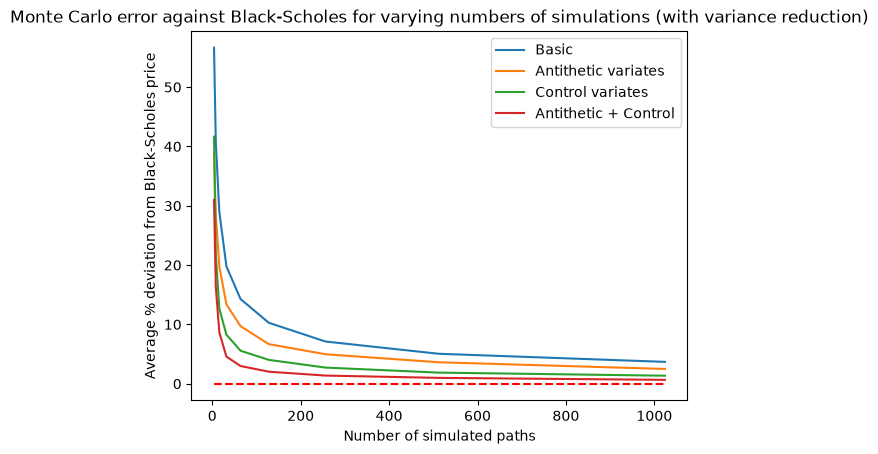

In [3]:
n_vals = [4, 8, 16, 32, 64, 128, 256, 512, 1024]

mean_errors_basic = []
mean_errors_antithetic = []
mean_errors_control = []
mean_errors_antithetic_control = []

for n in n_vals:
    error_basic = 0
    error_antithetic = 0
    error_control = 0
    error_antithetic_control = 0

    for i in range(1000):
        option_value_estimate_basic, _ = MC_value_option(
            call=True,
            n_paths=n,
            S0=100,
            K=100,
            r=0.05,
            vol=0.2,
            T=1,
            alpha=0.05
        )

        option_value_estimate_antithetic, _ = MC_value_option_antithetic(
            call=True,
            n_paths=n,
            S0=100,
            K=100,
            r=0.05,
            vol=0.2,
            T=1,
            alpha=0.05
        )

        option_value_estimate_control, _ = MC_value_option_control(
            call=True,
            n_paths=n,
            S0=100,
            K=100,
            r=0.05,
            vol=0.2,
            T=1,
            alpha=0.05
        )

        option_value_estimate_antithetic_control, _ = MC_value_option_antithetic_control(
            call=True,
            n_paths=n,
            S0=100,
            K=100,
            r=0.05,
            vol=0.2,
            T=1,
            alpha=0.05
        )

        option_value_BS, _ = BlackScholes(
            call=True,
            S0=100,
            K=100,
            r=0.05,
            vol=0.2,
            T=1
        )

        error_basic += 100 * abs(option_value_estimate_basic - option_value_BS) / option_value_BS
        error_antithetic += 100 * abs(option_value_estimate_antithetic - option_value_BS) / option_value_BS
        error_control += 100 * abs(option_value_estimate_control - option_value_BS) / option_value_BS
        error_antithetic_control += 100 * abs(option_value_estimate_antithetic_control - option_value_BS) / option_value_BS

    mean_error_basic = error_basic / 1000
    mean_error_antithetic = error_antithetic / 1000
    mean_error_control = error_control / 1000
    mean_error_antithetic_control = error_antithetic_control / 1000

    mean_errors_basic.append(mean_error_basic)
    mean_errors_antithetic.append(mean_error_antithetic)
    mean_errors_control.append(mean_error_control)
    mean_errors_antithetic_control.append(mean_error_antithetic_control)


plt.figure()
plt.plot(n_vals, mean_errors_basic)
plt.plot(n_vals, mean_errors_antithetic)
plt.plot(n_vals, mean_errors_control)
plt.plot(n_vals, mean_errors_antithetic_control)
plt.plot(n_vals, np.zeros(len(n_vals)), c='r', linestyle='--')

plt.title("Monte Carlo error against Black-Scholes for varying numbers of simulations (with variance reduction)")
plt.xlabel("Number of simulated paths")
plt.ylabel("Average % deviation from Black-Scholes price")

plt.legend(["Basic", "Antithetic variates", "Control variates", "Antithetic + Control"])
plt.show()

While using antithetic variates increases the speed of convergence over the basic Monte Carlo method, control variates have a greater effect, and combining both methods leads to the fastest convergence of all. We again use the log transform to extract the linear pattern:

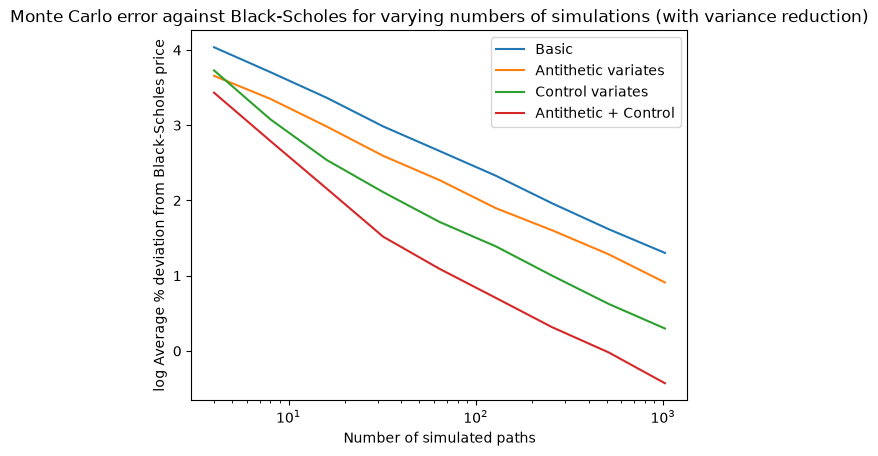

In [4]:
n_vals = [4, 8, 16, 32, 64, 128, 256, 512, 1024]

log_mean_errors_basic = np.log(np.array(mean_errors_basic))
log_mean_errors_antithetic = np.log(np.array(mean_errors_antithetic))
log_mean_errors_control = np.log(np.array(mean_errors_control))
log_mean_errors_antithetic_control = np.log(np.array(mean_errors_antithetic_control))


plt.figure()
plt.plot(n_vals, log_mean_errors_basic)
plt.plot(n_vals, log_mean_errors_antithetic)
plt.plot(n_vals, log_mean_errors_control)
plt.plot(n_vals, log_mean_errors_antithetic_control)

plt.title("Monte Carlo error against Black-Scholes for varying numbers of simulations (with variance reduction)")
plt.xlabel("Number of simulated paths")
plt.ylabel("log Average % deviation from Black-Scholes price")
plt.xscale('log')

plt.legend(["Basic", "Antithetic variates", "Control variates", "Antithetic + Control"])
plt.show()

The above plot reveals that all 4 of our methods have a similar order of convergence, $O(n^{-\frac{1}{2}})$, but the combination of antithetic and control variates yields the smallest coefficient $C > 0$ such that
$$
e_{AV,CV}^{(k)} = Ck^{-\frac{1}{2}}.
$$